### MACHINE LEARNING — CHURN PREDICTION MODEL

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, f1_score,
                             accuracy_score)
from sklearn.inspection import permutation_importance
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
# STEP 1: PREPARE DATA FOR MODELING
feature_cols = [
    'tenure_months', 'monthly_charges_usd', 'total_logins_90d',
    'days_since_last_login', 'avg_session_duration_min',
    'features_used_pct', 'integrations_connected', 'api_calls_30d',
    'data_storage_used_pct', 'reports_generated_30d',
    'team_members_active', 'support_tickets_90d',
    'avg_ticket_resolution_hrs', 'nps_score', 'csat_score',
    'payment_delays_6m', 'discount_applied_pct',
    'has_dedicated_csm', 'onboarding_completed',
    'training_sessions_attended', 'engagement_score', 'health_score',
    'support_burden', 'revenue_per_member', 'is_high_value'
]
df_cleaned = pd.read_csv("saas_churn_cleaned.csv")

In [3]:
# Encode categorical features
le_plan = LabelEncoder()
df_cleaned['plan_encoded'] = le_plan.fit_transform(df_cleaned['subscription_plan'])
feature_cols.append('plan_encoded')

le_contract = LabelEncoder()
df_cleaned['contract_encoded'] = le_contract.fit_transform(df_cleaned['contract_type'])
feature_cols.append('contract_encoded')

le_size = LabelEncoder()
df_cleaned['size_encoded'] = le_size.fit_transform(df_cleaned['company_size'])
feature_cols.append('size_encoded')

X = df_cleaned[feature_cols].copy()
y = df_cleaned['churned'].copy()

In [4]:
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Class distribution:\n{y.value_counts()}")
print(f"Class ratio: {y.mean()*100:.1f}% churned")

Features: 28
Samples: 5000
Class distribution:
churned
0    4280
1     720
Name: count, dtype: int64
Class ratio: 14.4% churned


In [5]:
# STEP 2: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Train set: 4000 samples
Test set: 1000 samples


In [6]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# STEP 3: TRAIN MULTIPLE MODELS
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=42, subsample=0.8
    )
}

In [8]:
results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")

    # Use scaled data for Logistic Regression, unscaled for tree models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Cross validation
    if name == 'Logistic Regression':
        cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                     cv=5, scoring='roc_auc')
    else:
        cv_scores = cross_val_score(model, X_train, y_train,
                                     cv=5, scoring='roc_auc')


--- Logistic Regression ---

--- Random Forest ---

--- Gradient Boosting ---


In [9]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy,
        'f1': f1,
        'auc': auc,
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std()
}

In [10]:
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(f"CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
          target_names=['Active', 'Churned']))

Accuracy: 0.8540
F1 Score: 0.1889
ROC-AUC: 0.7119
CV AUC: 0.6765 (+/- 0.0220)

Classification Report:
              precision    recall  f1-score   support

      Active       0.87      0.98      0.92       856
     Churned       0.47      0.12      0.19       144

    accuracy                           0.85      1000
   macro avg       0.67      0.55      0.55      1000
weighted avg       0.81      0.85      0.81      1000



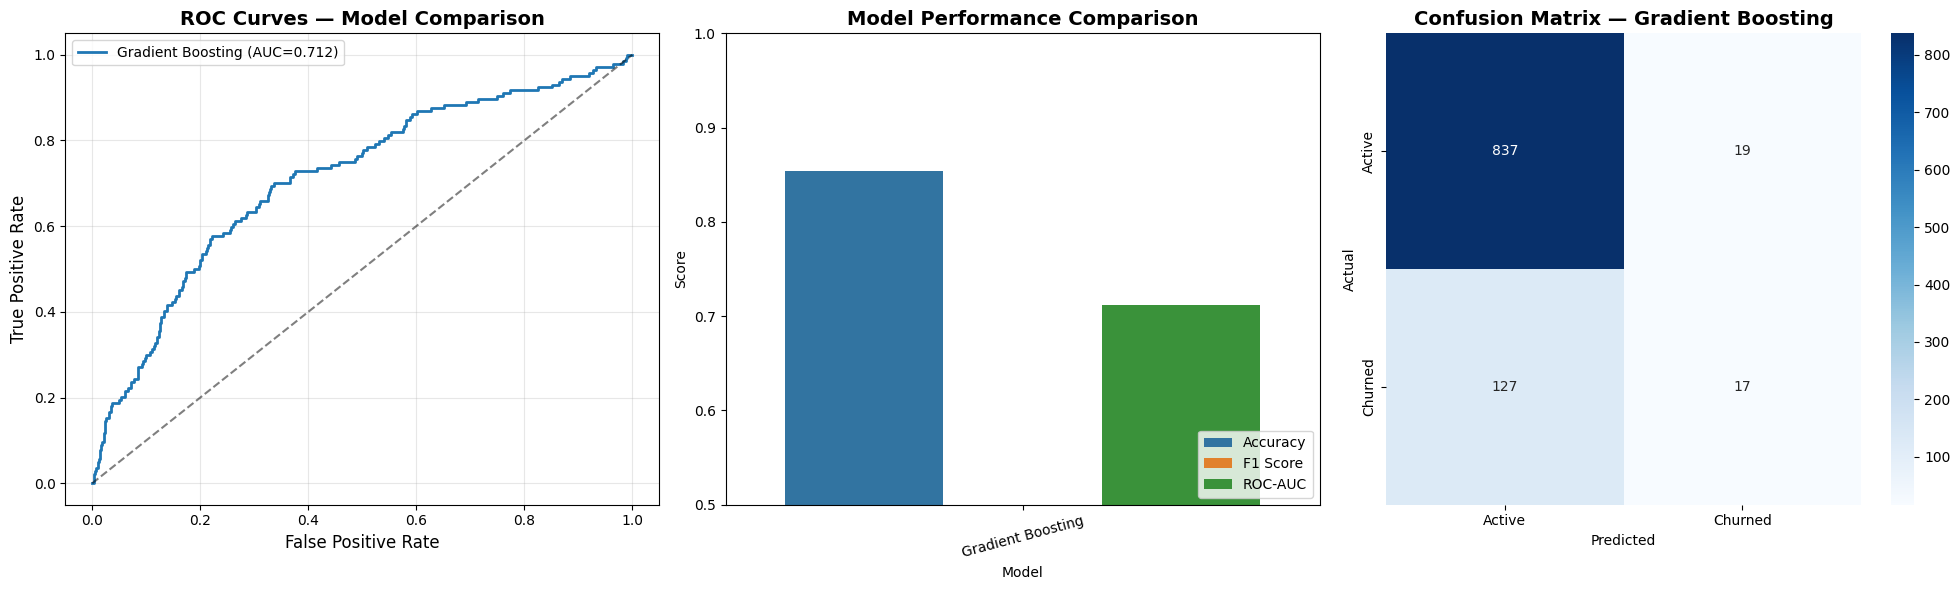


🏆 BEST MODEL: Gradient Boosting (AUC: 0.7119)


In [11]:
# STEP 4: MODEL COMPARISON VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 4a. ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})",
                 linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — Model Comparison',
                   fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 4b. Metrics Comparison
model_names = list(results.keys())
metrics_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': [results[m]['accuracy'] for m in model_names],
    'F1 Score': [results[m]['f1'] for m in model_names],
    'ROC-AUC': [results[m]['auc'] for m in model_names]
})
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric',
                                  value_name='Score')
sns.barplot(data=metrics_melted, x='Model', y='Score', hue='Metric',
            ax=axes[1])
axes[1].set_title('Model Performance Comparison',
                   fontsize=14, fontweight='bold')
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='lower right')

# 4c. Best Model Confusion Matrix
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_result = results[best_model_name]
cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
axes[2].set_title(f'Confusion Matrix — {best_model_name}',
                   fontsize=14, fontweight='bold')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print(f"\n🏆 BEST MODEL: {best_model_name} "
      f"(AUC: {best_result['auc']:.4f})")

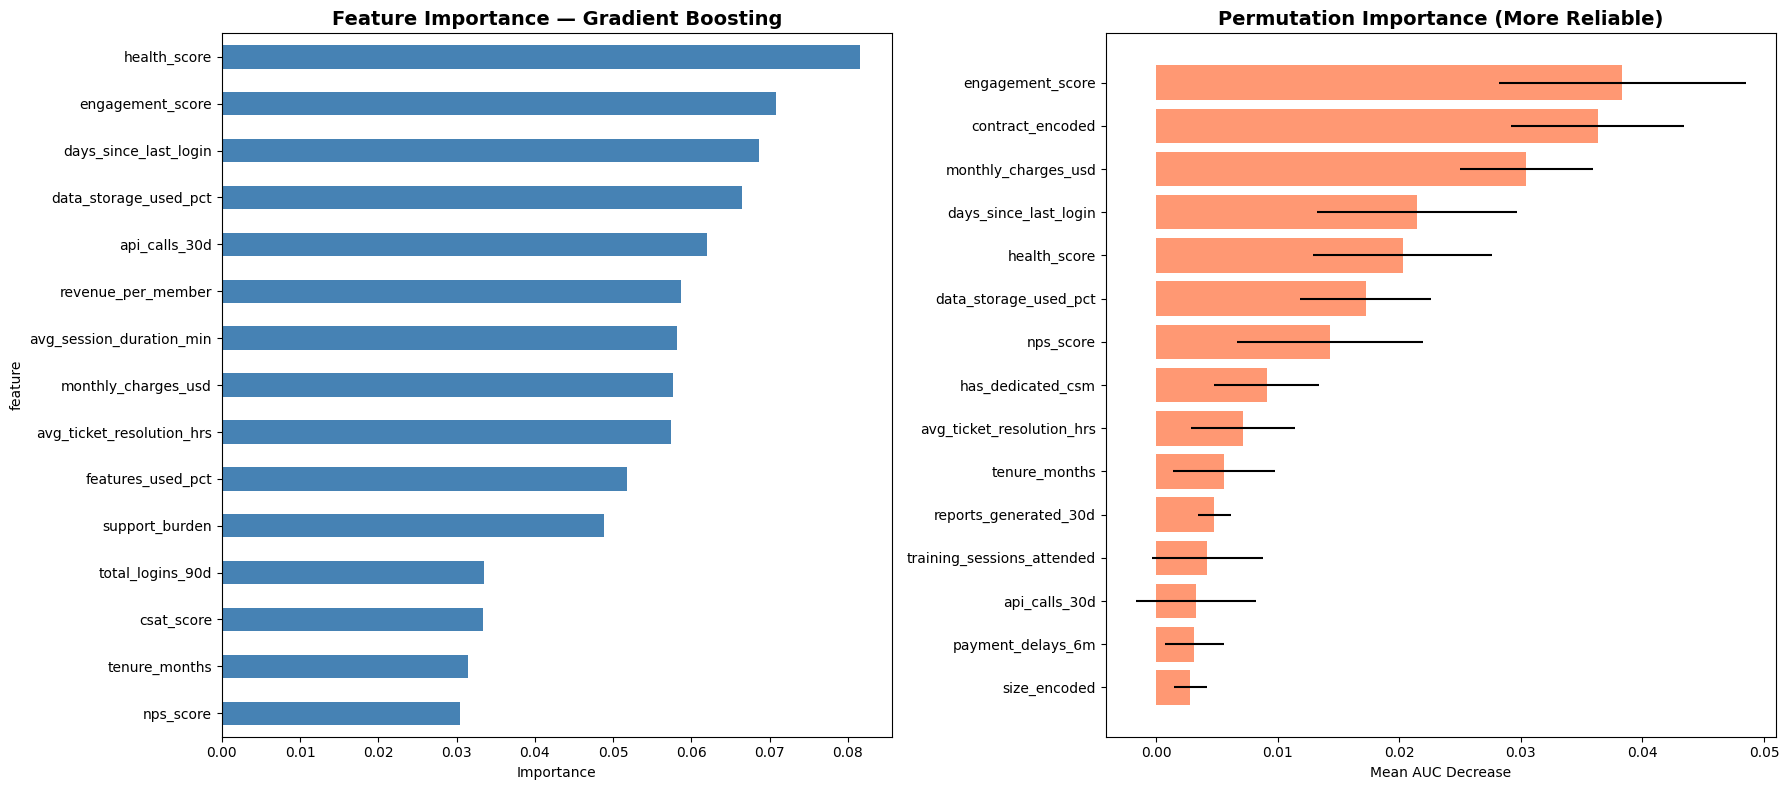

In [12]:
# STEP 5: FEATURE IMPORTANCE (Critical for Business Insights)
best_model = results[best_model_name]['model']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=True).tail(15)

    feat_imp.plot(x='feature', y='importance', kind='barh', ax=axes[0],
                  color='steelblue', legend=False)
    axes[0].set_title(f'Feature Importance — {best_model_name}',
                       fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Importance')

# Permutation Importance (model-agnostic)
perm_imp = permutation_importance(
    best_model, X_test, y_test, n_repeats=10,
    random_state=42, scoring='roc_auc'
)
perm_imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_imp.importances_mean,
    'importance_std': perm_imp.importances_std
}).sort_values('importance_mean', ascending=True).tail(15)

axes[1].barh(perm_imp_df['feature'], perm_imp_df['importance_mean'],
             xerr=perm_imp_df['importance_std'], color='coral', alpha=0.8)
axes[1].set_title('Permutation Importance (More Reliable)',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean AUC Decrease')

plt.tight_layout()
plt.show()

In [13]:
# Print top features
print("🔑 TOP CHURN PREDICTORS")
top_features = perm_imp_df.sort_values(
    'importance_mean', ascending=False).head(10)
for _, row in top_features.iterrows():
    print(f"  {row['feature']}: {row['importance_mean']:.4f} "
          f"(+/- {row['importance_std']:.4f})")

🔑 TOP CHURN PREDICTORS
  engagement_score: 0.0383 (+/- 0.0102)
  contract_encoded: 0.0363 (+/- 0.0071)
  monthly_charges_usd: 0.0304 (+/- 0.0054)
  days_since_last_login: 0.0215 (+/- 0.0082)
  health_score: 0.0203 (+/- 0.0073)
  data_storage_used_pct: 0.0173 (+/- 0.0054)
  nps_score: 0.0143 (+/- 0.0076)
  has_dedicated_csm: 0.0091 (+/- 0.0043)
  avg_ticket_resolution_hrs: 0.0072 (+/- 0.0043)
  tenure_months: 0.0056 (+/- 0.0042)


In [14]:
# STEP 6: GENERATE PREDICTIONS FOR ALL ACTIVE CUSTOMERS
active_customers = df_cleaned[df_cleaned['churned'] == 0].copy()
X_active = active_customers[feature_cols].fillna(X.median())

if best_model_name == 'Logistic Regression':
    X_active_input = scaler.transform(X_active)
else:
    X_active_input = X_active

active_customers['churn_probability'] = best_model.predict_proba(
    X_active_input)[:, 1]
active_customers['churn_prediction'] = best_model.predict(X_active_input)
active_customers['risk_level'] = pd.cut(
    active_customers['churn_probability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical']
)

In [15]:
print(f"\nActive Customers: {len(active_customers)}")
print(f"\nRisk Distribution:")
print(active_customers['risk_level'].value_counts())
print(f"\nPredicted to churn: "
      f"{active_customers['churn_prediction'].sum()}")


Active Customers: 4280

Risk Distribution:
risk_level
Low Risk       4219
Medium Risk      42
High Risk        10
Critical          9
Name: count, dtype: int64

Predicted to churn: 19


In [16]:
# Save predictions
output_cols = [
    'customer_id', 'company_name', 'industry', 'company_size',
    'subscription_plan', 'monthly_charges_usd', 'contract_type',
    'tenure_months', 'days_since_last_login', 'support_tickets_90d',
    'nps_score', 'engagement_score', 'health_score',
    'churn_probability', 'churn_prediction', 'risk_level'
]

active_customers[output_cols].sort_values(
    'churn_probability', ascending=False
).to_csv('churn_predictions_active_customers.csv', index=False)


In [17]:
# Save model
pickle.dump(best_model, open('churn_model.pkl', 'wb'))
pickle.dump(scaler, open('saasmodel.pkl', 'wb'))
print(f"\n✅ Predictions saved: churn_predictions_active_customers.csv")
print(f"✅ Model saved: churn_model.pkl")


✅ Predictions saved: churn_predictions_active_customers.csv
✅ Model saved: churn_model.pkl


In [18]:
# Full dataset with predictions for Power BI
full_output = df_cleaned.copy()
if best_model_name == 'Logistic Regression':
    X_all = scaler.transform(df_cleaned[feature_cols].fillna(X.median()))
else:
    X_all = df_cleaned[feature_cols].fillna(X.median())

full_output['churn_probability'] = best_model.predict_proba(X_all)[:, 1]
full_output['predicted_risk_level'] = pd.cut(
    full_output['churn_probability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical']
)
full_output.to_csv('saas_churn_full_for_powerbi.csv', index=False)
print(f"✅ Full dataset for Power BI: saas_churn_full_for_powerbi.csv")

✅ Full dataset for Power BI: saas_churn_full_for_powerbi.csv
